# Robustness and Sensitivity Checks

This notebook evaluates the reliability of the causal estimation workflow using:

- a placebo-treatment test,
- an omitted-confounder sensitivity analysis,
- propensity-score overlap diagnostics,
- and automated validation checks.

A robust causal workflow should estimate an effect close to zero after the treatment assignment is randomly permuted.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd


current_path = Path.cwd().resolve()

if (current_path / "README.md").exists():
    PROJECT_ROOT = current_path
else:
    PROJECT_ROOT = current_path.parent


OBSERVED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_retention_observed.csv"
)

FULL_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_retention_full.csv"
)


observed_df = pd.read_csv(
    OBSERVED_DATA_PATH
)

full_df = pd.read_csv(
    FULL_DATA_PATH
)


numeric_features = [
    "age",
    "tenure",
    "spend",
    "complaints",
    "satisfaction",
    "engagement",
]

categorical_features = [
    "region",
]

causal_features = (
    numeric_features
    + categorical_features
)


assert len(observed_df) == len(full_df)
assert observed_df.index.equals(full_df.index)

assert observed_df.isna().sum().sum() == 0
assert full_df.isna().sum().sum() == 0

assert "treatment" not in causal_features
assert "outcome" not in causal_features


print("Observed data shape:", observed_df.shape)
print("Full data shape:", full_df.shape)

print(
    "Observed treatment rate:",
    observed_df["treatment"].mean(),
)

print(
    "Observed outcome rate:",
    observed_df["outcome"].mean(),
)

print(
    "Causal features:",
    causal_features,
)

print(
    "True probability-scale ATE:",
    full_df["true_cate"].mean(),
)

print(
    "Rows aligned:",
    observed_df.index.equals(full_df.index),
)

Observed data shape: (6000, 9)
Full data shape: (6000, 19)
Observed treatment rate: 0.283
Observed outcome rate: 0.45516666666666666
Causal features: ['age', 'tenure', 'spend', 'complaints', 'satisfaction', 'engagement', 'region']
True probability-scale ATE: 0.15836461343754135
Rows aligned: True


## 2. Reusable Cross-Fitted AIPW Estimator

A reusable AIPW function is defined so that the same estimation pipeline can be applied to:

- the original treatment,
- a randomly permuted placebo treatment,
- and reduced feature sets.

Using the same implementation makes the robustness comparisons consistent.

In [3]:
from dataclasses import dataclass

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


@dataclass
class AIPWResult:
    estimate: float
    standard_error: float
    ci_lower: float
    ci_upper: float
    propensity: np.ndarray
    mu0: np.ndarray
    mu1: np.ndarray
    score: np.ndarray
    clipped_count: int


def build_preprocessor(feature_names):
    numeric_subset = [
        column
        for column in numeric_features
        if column in feature_names
    ]

    categorical_subset = [
        column
        for column in categorical_features
        if column in feature_names
    ]

    transformers = []

    if numeric_subset:
        transformers.append(
            (
                "numeric",
                StandardScaler(),
                numeric_subset,
            )
        )

    if categorical_subset:
        transformers.append(
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
                categorical_subset,
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )


def build_logistic_pipeline(feature_names):
    return Pipeline(
        steps=[
            (
                "preprocessing",
                build_preprocessor(feature_names),
            ),
            (
                "logistic_regression",
                LogisticRegression(
                    max_iter=1500,
                    random_state=42,
                ),
            ),
        ]
    )


def estimate_aipw(
    data,
    feature_names,
    treatment_col="treatment",
    outcome_col="outcome",
    n_splits=3,
    random_state=42,
):
    working_df = (
        data
        .reset_index(drop=True)
        .copy()
    )

    number_of_rows = len(working_df)

    raw_propensity = np.zeros(
        number_of_rows
    )

    mu0_hat = np.zeros(
        number_of_rows
    )

    mu1_hat = np.zeros(
        number_of_rows
    )

    folds = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    )

    for train_index, test_index in folds.split(
        working_df
    ):
        fold_train = working_df.iloc[
            train_index
        ]

        fold_test = working_df.iloc[
            test_index
        ]

        control_mask = (
            fold_train[treatment_col] == 0
        )

        treated_mask = (
            fold_train[treatment_col] == 1
        )

        propensity_model = (
            build_logistic_pipeline(
                feature_names
            )
        )

        outcome_model_0 = (
            build_logistic_pipeline(
                feature_names
            )
        )

        outcome_model_1 = (
            build_logistic_pipeline(
                feature_names
            )
        )

        propensity_model.fit(
            fold_train[feature_names],
            fold_train[treatment_col],
        )

        outcome_model_0.fit(
            fold_train.loc[
                control_mask,
                feature_names,
            ],
            fold_train.loc[
                control_mask,
                outcome_col,
            ],
        )

        outcome_model_1.fit(
            fold_train.loc[
                treated_mask,
                feature_names,
            ],
            fold_train.loc[
                treated_mask,
                outcome_col,
            ],
        )

        raw_propensity[test_index] = (
            propensity_model.predict_proba(
                fold_test[feature_names]
            )[:, 1]
        )

        mu0_hat[test_index] = (
            outcome_model_0.predict_proba(
                fold_test[feature_names]
            )[:, 1]
        )

        mu1_hat[test_index] = (
            outcome_model_1.predict_proba(
                fold_test[feature_names]
            )[:, 1]
        )

    propensity = np.clip(
        raw_propensity,
        0.03,
        0.97,
    )

    treatment = working_df[
        treatment_col
    ].to_numpy(dtype=float)

    outcome = working_df[
        outcome_col
    ].to_numpy(dtype=float)

    aipw_score = (
        mu1_hat
        - mu0_hat
        + treatment
        * (outcome - mu1_hat)
        / propensity
        - (1 - treatment)
        * (outcome - mu0_hat)
        / (1 - propensity)
    )

    estimate = aipw_score.mean()

    standard_error = (
        aipw_score.std(ddof=1)
        / np.sqrt(number_of_rows)
    )

    ci_lower = (
        estimate
        - 1.96 * standard_error
    )

    ci_upper = (
        estimate
        + 1.96 * standard_error
    )

    clipped_count = int(
        np.sum(
            raw_propensity
            != propensity
        )
    )

    assert np.isfinite(propensity).all()
    assert np.isfinite(mu0_hat).all()
    assert np.isfinite(mu1_hat).all()
    assert np.isfinite(aipw_score).all()

    return AIPWResult(
        estimate=estimate,
        standard_error=standard_error,
        ci_lower=ci_lower,
        ci_upper=ci_upper,
        propensity=propensity,
        mu0=mu0_hat,
        mu1=mu1_hat,
        score=aipw_score,
        clipped_count=clipped_count,
    )


print("AIPWResult class defined.")
print("AIPW estimator function defined.")
print("Number of full causal features:", len(causal_features))

AIPWResult class defined.
AIPW estimator function defined.
Number of full causal features: 7


## 3. Reference AIPW Estimate

The reusable estimator is first applied to the original observed data.

This reference result will be compared with the placebo and omitted-confounder estimates.

In [4]:
reference_result = estimate_aipw(
    data=observed_df,
    feature_names=causal_features,
    treatment_col="treatment",
    outcome_col="outcome",
    n_splits=3,
    random_state=42,
)


true_probability_ate = full_df[
    "true_cate"
].mean()

reference_bias = (
    reference_result.estimate
    - true_probability_ate
)


print(
    "Reference AIPW estimate:",
    reference_result.estimate,
)

print(
    "Reference standard error:",
    reference_result.standard_error,
)

print(
    "Reference 95% confidence interval:",
    (
        reference_result.ci_lower,
        reference_result.ci_upper,
    ),
)

print(
    "True probability-scale ATE:",
    true_probability_ate,
)

print(
    "Reference estimation bias:",
    reference_bias,
)

print(
    "Minimum cross-fitted propensity:",
    reference_result.propensity.min(),
)

print(
    "Maximum cross-fitted propensity:",
    reference_result.propensity.max(),
)

print(
    "Number of clipped propensities:",
    reference_result.clipped_count,
)

Reference AIPW estimate: 0.15903890917743183
Reference standard error: 0.014461268377706078
Reference 95% confidence interval: (np.float64(0.1306948231571279), np.float64(0.18738299519773574))
True probability-scale ATE: 0.15836461343754135
Reference estimation bias: 0.0006742957398904736
Minimum cross-fitted propensity: 0.12068249858766407
Maximum cross-fitted propensity: 0.6859910219551432
Number of clipped propensities: 0


## 4. Placebo Treatment Test

The observed treatment assignments are randomly permuted across customers.

This preserves the treatment rate but breaks the original relationship between treatment, customer characteristics, and outcome. A reliable causal pipeline should estimate a placebo effect close to zero.

In [5]:
placebo_rng = np.random.default_rng(
    141
)


placebo_df = observed_df.copy()


placebo_df[
    "placebo_treatment"
] = placebo_rng.permutation(
    observed_df[
        "treatment"
    ].to_numpy()
)


placebo_result = estimate_aipw(
    data=placebo_df,
    feature_names=causal_features,
    treatment_col="placebo_treatment",
    outcome_col="outcome",
    n_splits=3,
    random_state=42,
)


placebo_z_score = (
    placebo_result.estimate
    / placebo_result.standard_error
)


placebo_is_small = (
    abs(placebo_result.estimate)
    < 2.5 * placebo_result.standard_error
)


assert (
    placebo_df["placebo_treatment"].mean()
    == observed_df["treatment"].mean()
)

assert np.array_equal(
    np.sort(
        placebo_df[
            "placebo_treatment"
        ].to_numpy()
    ),
    np.sort(
        observed_df[
            "treatment"
        ].to_numpy()
    ),
)


print(
    "Original treatment rate:",
    observed_df["treatment"].mean(),
)

print(
    "Placebo treatment rate:",
    placebo_df[
        "placebo_treatment"
    ].mean(),
)

print(
    "Placebo AIPW estimate:",
    placebo_result.estimate,
)

print(
    "Placebo standard error:",
    placebo_result.standard_error,
)

print(
    "Placebo 95% confidence interval:",
    (
        placebo_result.ci_lower,
        placebo_result.ci_upper,
    ),
)

print(
    "Placebo z-score:",
    placebo_z_score,
)

print(
    "Placebo estimate is small:",
    placebo_is_small,
)

print(
    "Number of clipped propensities:",
    placebo_result.clipped_count,
)

Original treatment rate: 0.283
Placebo treatment rate: 0.283
Placebo AIPW estimate: -0.006247871052541415
Placebo standard error: 0.014226330603645938
Placebo 95% confidence interval: (np.float64(-0.03413147903568745), np.float64(0.021635736930604624))
Placebo z-score: -0.43917656819673545
Placebo estimate is small: True
Number of clipped propensities: 0


## 5. Omitted-Confounder Sensitivity Analysis

Satisfaction and engagement are intentionally removed from the adjustment set.

This analysis evaluates how sensitive the AIPW estimate is to an incomplete set of observed confounders. A small change does not prove that omitted confounding is harmless; it only describes sensitivity in this simulated dataset.

In [6]:
omitted_confounders = [
    "satisfaction",
    "engagement",
]


reduced_features = [
    feature
    for feature in causal_features
    if feature not in omitted_confounders
]


reduced_result = estimate_aipw(
    data=observed_df,
    feature_names=reduced_features,
    treatment_col="treatment",
    outcome_col="outcome",
    n_splits=3,
    random_state=42,
)


reduced_bias = (
    reduced_result.estimate
    - true_probability_ate
)


estimate_change = (
    reduced_result.estimate
    - reference_result.estimate
)


absolute_bias_change = (
    abs(reduced_bias)
    - abs(reference_bias)
)


assert all(
    confounder not in reduced_features
    for confounder in omitted_confounders
)

assert len(reduced_features) == (
    len(causal_features)
    - len(omitted_confounders)
)


print(
    "Omitted confounders:",
    omitted_confounders,
)

print(
    "Reduced causal features:",
    reduced_features,
)

print(
    "Reference AIPW estimate:",
    reference_result.estimate,
)

print(
    "Reduced-feature AIPW estimate:",
    reduced_result.estimate,
)

print(
    "Reduced-feature standard error:",
    reduced_result.standard_error,
)

print(
    "Reduced-feature 95% confidence interval:",
    (
        reduced_result.ci_lower,
        reduced_result.ci_upper,
    ),
)

print(
    "Change from reference estimate:",
    estimate_change,
)

print(
    "Reduced-feature estimation bias:",
    reduced_bias,
)

print(
    "Change in absolute bias:",
    absolute_bias_change,
)

print(
    "Number of clipped propensities:",
    reduced_result.clipped_count,
)

Omitted confounders: ['satisfaction', 'engagement']
Reduced causal features: ['age', 'tenure', 'spend', 'complaints', 'region']
Reference AIPW estimate: 0.15903890917743183
Reduced-feature AIPW estimate: 0.15775754282153617
Reduced-feature standard error: 0.014306427488549775
Reduced-feature 95% confidence interval: (np.float64(0.12971694494397862), np.float64(0.18579814069909373))
Change from reference estimate: -0.0012813663558956523
Reduced-feature estimation bias: -0.0006070706160051786
Change in absolute bias: -6.7225123885295e-05
Number of clipped propensities: 0


## 6. Propensity-Score Overlap Diagnostics

The cross-fitted propensity-score distributions are compared between treated and untreated customers.

Adequate overlap indicates that customers with similar observed characteristics appear in both treatment groups. Weak overlap can produce unstable weights and unreliable causal estimates.

Treated propensity range: (np.float64(0.12068249858766407), np.float64(0.5951201952677667))
Control propensity range: (np.float64(0.12636500429394712), np.float64(0.6859910219551432))
Empirical overlap interval: (np.float64(0.12636500429394712), np.float64(0.5951201952677667))
Customers outside empirical overlap: 4
Customers with extreme propensity: 0
Maximum treated weight: 8.286205636301087
Maximum control weight: 3.1846223194839607


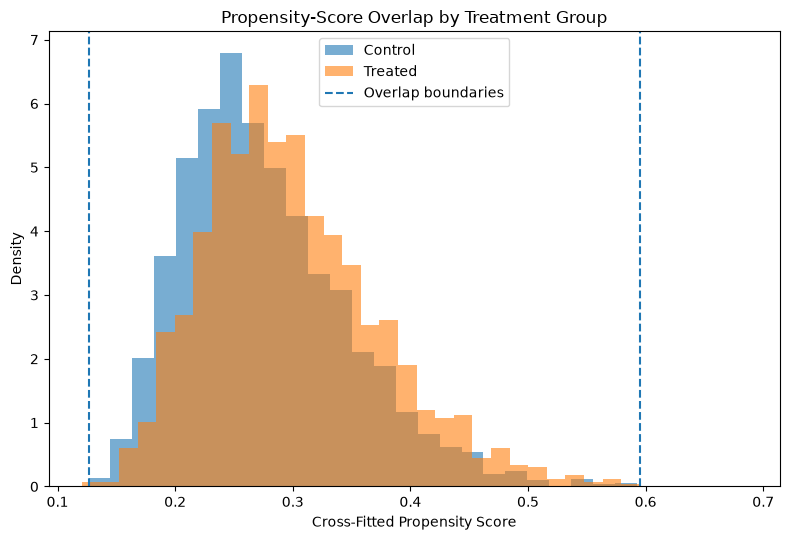

Overlap figure saved to: D:\article28-unet-projects\predictive-vs-causal-decision-lab\reports\figures\propensity_score_overlap.png
Overlap figure exists: True


In [7]:
import matplotlib.pyplot as plt


treatment_array = observed_df[
    "treatment"
].to_numpy()


treated_propensity = (
    reference_result.propensity[
        treatment_array == 1
    ]
)

control_propensity = (
    reference_result.propensity[
        treatment_array == 0
    ]
)


overlap_lower = max(
    treated_propensity.min(),
    control_propensity.min(),
)

overlap_upper = min(
    treated_propensity.max(),
    control_propensity.max(),
)


outside_overlap_count = np.sum(
    (reference_result.propensity < overlap_lower)
    | (reference_result.propensity > overlap_upper)
)


extreme_propensity_count = np.sum(
    (reference_result.propensity < 0.10)
    | (reference_result.propensity > 0.90)
)


treated_weights = (
    1 / treated_propensity
)

control_weights = (
    1 / (1 - control_propensity)
)


print(
    "Treated propensity range:",
    (
        treated_propensity.min(),
        treated_propensity.max(),
    ),
)

print(
    "Control propensity range:",
    (
        control_propensity.min(),
        control_propensity.max(),
    ),
)

print(
    "Empirical overlap interval:",
    (
        overlap_lower,
        overlap_upper,
    ),
)

print(
    "Customers outside empirical overlap:",
    outside_overlap_count,
)

print(
    "Customers with extreme propensity:",
    extreme_propensity_count,
)

print(
    "Maximum treated weight:",
    treated_weights.max(),
)

print(
    "Maximum control weight:",
    control_weights.max(),
)


REPORTS_FIGURES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

REPORTS_FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


overlap_figure_path = (
    REPORTS_FIGURES_DIR
    / "propensity_score_overlap.png"
)


plt.figure(
    figsize=(8, 5.5)
)

plt.hist(
    control_propensity,
    bins=30,
    alpha=0.6,
    density=True,
    label="Control",
)

plt.hist(
    treated_propensity,
    bins=30,
    alpha=0.6,
    density=True,
    label="Treated",
)

plt.axvline(
    overlap_lower,
    linestyle="--",
    linewidth=1.5,
    label="Overlap boundaries",
)

plt.axvline(
    overlap_upper,
    linestyle="--",
    linewidth=1.5,
)

plt.xlabel(
    "Cross-Fitted Propensity Score"
)

plt.ylabel(
    "Density"
)

plt.title(
    "Propensity-Score Overlap by Treatment Group"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    overlap_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Overlap figure saved to:",
    overlap_figure_path,
)

print(
    "Overlap figure exists:",
    overlap_figure_path.exists(),
)

## 7. Robustness Summary

The reference, placebo, omitted-confounder, and overlap results are consolidated into reproducible summary tables.

Automated checks verify that the placebo effect is small, the true effect lies within the reference confidence interval, and propensity-score overlap is adequate.

In [8]:
robustness_summary = pd.DataFrame(
    {
        "analysis": [
            "Reference AIPW",
            "Placebo Treatment",
            "Omitted Confounders",
        ],
        "estimate": [
            reference_result.estimate,
            placebo_result.estimate,
            reduced_result.estimate,
        ],
        "standard_error": [
            reference_result.standard_error,
            placebo_result.standard_error,
            reduced_result.standard_error,
        ],
        "ci_lower_95": [
            reference_result.ci_lower,
            placebo_result.ci_lower,
            reduced_result.ci_lower,
        ],
        "ci_upper_95": [
            reference_result.ci_upper,
            placebo_result.ci_upper,
            reduced_result.ci_upper,
        ],
        "target_effect": [
            true_probability_ate,
            0.0,
            true_probability_ate,
        ],
    }
)


robustness_summary[
    "signed_error"
] = (
    robustness_summary["estimate"]
    - robustness_summary["target_effect"]
)

robustness_summary[
    "absolute_error"
] = robustness_summary[
    "signed_error"
].abs()


overlap_fraction = (
    1
    - outside_overlap_count
    / len(observed_df)
)


overlap_summary = pd.DataFrame(
    {
        "metric": [
            "treated_propensity_min",
            "treated_propensity_max",
            "control_propensity_min",
            "control_propensity_max",
            "overlap_lower",
            "overlap_upper",
            "customers_outside_overlap",
            "overlap_fraction",
            "extreme_propensity_count",
            "maximum_treated_weight",
            "maximum_control_weight",
        ],
        "value": [
            treated_propensity.min(),
            treated_propensity.max(),
            control_propensity.min(),
            control_propensity.max(),
            overlap_lower,
            overlap_upper,
            outside_overlap_count,
            overlap_fraction,
            extreme_propensity_count,
            treated_weights.max(),
            control_weights.max(),
        ],
    }
)


reference_ci_contains_truth = (
    reference_result.ci_lower
    <= true_probability_ate
    <= reference_result.ci_upper
)

adequate_overlap = (
    overlap_fraction >= 0.99
)

no_extreme_propensity = (
    extreme_propensity_count == 0
)


assert placebo_is_small
assert reference_ci_contains_truth
assert adequate_overlap
assert no_extreme_propensity

assert np.isfinite(
    robustness_summary[
        [
            "estimate",
            "standard_error",
            "ci_lower_95",
            "ci_upper_95",
            "target_effect",
            "signed_error",
            "absolute_error",
        ]
    ].to_numpy()
).all()


REPORTS_TABLES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "tables"
)

REPORTS_TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


robustness_summary_path = (
    REPORTS_TABLES_DIR
    / "robustness_summary.csv"
)

overlap_summary_path = (
    REPORTS_TABLES_DIR
    / "overlap_diagnostics.csv"
)


robustness_summary.to_csv(
    robustness_summary_path,
    index=False,
)

overlap_summary.to_csv(
    overlap_summary_path,
    index=False,
)


assert robustness_summary_path.exists()
assert overlap_summary_path.exists()


display(robustness_summary)
display(overlap_summary)


print(
    "Placebo check passed:",
    placebo_is_small,
)

print(
    "Reference CI contains true ATE:",
    reference_ci_contains_truth,
)

print(
    "Adequate empirical overlap:",
    adequate_overlap,
)

print(
    "No extreme propensities:",
    no_extreme_propensity,
)

print(
    "Robustness table saved to:",
    robustness_summary_path,
)

print(
    "Overlap table saved to:",
    overlap_summary_path,
)

print(
    "All robustness checks passed."
)

,analysis,estimate,standard_error,ci_lower_95,ci_upper_95,target_effect,signed_error,absolute_error
0,Reference AIPW,0.159039,0.014461,0.130695,0.187383,0.158365,0.000674,0.000674
1,Placebo Treatment,-0.006248,0.014226,-0.034131,0.021636,0.000000,-0.006248,0.006248
2,Omitted Confounders,0.157758,0.014306,0.129717,0.185798,0.158365,-0.000607,0.000607


,metric,value
0,treated_propensity_min,0.120682
1,treated_propensity_max,0.595120
2,control_propensity_min,0.126365
3,control_propensity_max,0.685991
4,overlap_lower,0.126365
5,overlap_upper,0.595120
6,customers_outside_overlap,4.000000
7,overlap_fraction,0.999333
8,extreme_propensity_count,0.000000
9,maximum_treated_weight,8.286206


Placebo check passed: True
Reference CI contains true ATE: True
Adequate empirical overlap: True
No extreme propensities: True
Robustness table saved to: D:\article28-unet-projects\predictive-vs-causal-decision-lab\reports\tables\robustness_summary.csv
Overlap table saved to: D:\article28-unet-projects\predictive-vs-causal-decision-lab\reports\tables\overlap_diagnostics.csv
All robustness checks passed.
